# NO CONTACT Cancelled Reservations: Timing & Source Analysis

This notebook analyzes who cancels NO CONTACT reservations and when.

**Key identifiers:**
- EDI cancellations use `Knum` as reservation identifier
- Rez-Cancelled uses `REZ_NUM` as reservation identifier
- RCU/HRD is identified by `LocCode = '12'`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Hertz brand colors
HERTZ_YELLOW = '#F5C400'
CHARCOAL = '#1A1A1A'
DARK_GRAY = '#6E6E6E'
LIGHT_GRAY = '#E6E6E6'
RED = '#C62828'

## 1. Load Data

In [2]:
# Load Translog
translog = pd.read_csv('../data/raw/Translog (Partitioned) Nov-Dec 2025.csv', low_memory=False)
print(f'Translog records: {len(translog):,}')

# Load Conversion Data
conv = pd.read_excel('../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx', engine='openpyxl')
print(f'Conversion Data records: {len(conv):,}')

Translog records: 5,201,137
Conversion Data records: 68,360


## 2. Identify NO CONTACT Cancelled Reservations

In [3]:
# Filter to NO CONTACT + CANCEL_ID = 1
no_contact_cancel = conv[(conv['\nCONTACT_GROUP'] == 'NO CONTACT') & (conv['\nCANCEL_ID'] == 1)].copy()
no_contact_confirms = set(no_contact_cancel['\nCONFIRM_NUM'].astype(str).str.strip())
print(f'NO CONTACT cancelled reservations: {len(no_contact_confirms):,}')

NO CONTACT cancelled reservations: 4,346


## 3. Find Cancellation Events

**Important:** Different cancellation types use different identifiers:
- `Edi-Cancel` with `EMP_LNAME='EDI'` → Insurance partner cancellation, uses `Knum`
- `Rez-Cancelled` → Hertz employee cancellation, uses `REZ_NUM`

In [4]:
# Get EDI cancellations (use Knum as identifier)
edi_cancels = translog[(translog['MSG1'] == 'Edi-Cancel') & (translog['EMP_LNAME'] == 'EDI')].copy()
edi_cancels['res_id'] = edi_cancels['Knum'].astype(str).str.strip()
edi_cancels = edi_cancels[edi_cancels['res_id'].isin(no_contact_confirms)]
edi_cancels['cancel_source'] = 'Insurance (EDI)'
print(f'EDI cancellations matching NO CONTACT: {len(edi_cancels):,}')

# Get Rez-Cancelled (use REZ_NUM as identifier)
rez_cancels = translog[translog['MSG1'] == 'Rez-Cancelled'].copy()
rez_cancels['res_id'] = rez_cancels['REZ_NUM'].astype(str).str.strip()
rez_cancels = rez_cancels[rez_cancels['res_id'].isin(no_contact_confirms)]

# Categorize by LocCode: 12 = RCU/HRD, others = Branch
rez_cancels['cancel_source'] = rez_cancels['LocCode'].apply(
    lambda x: 'RCU/HRD' if str(x) == '12' else 'Branch'
)
print(f'Rez-Cancelled matching NO CONTACT: {len(rez_cancels):,}')
print(rez_cancels['cancel_source'].value_counts())

EDI cancellations matching NO CONTACT: 3,509
Rez-Cancelled matching NO CONTACT: 393
cancel_source
Branch     215
RCU/HRD    178
Name: count, dtype: int64


In [5]:
# Combine all cancellation events
all_cancels = pd.concat([edi_cancels, rez_cancels], ignore_index=True)
print(f'Total cancellation events: {len(all_cancels):,}')
print(f'Coverage: {len(all_cancels)/len(no_contact_confirms)*100:.1f}%')

Total cancellation events: 3,902
Coverage: 89.8%


## 4. Calculate Time to Cancellation

In [6]:
# Parse cancellation timestamps
all_cancels['cancel_datetime'] = pd.to_datetime(
    all_cancels['SystemDate'].astype(str), 
    format='%Y%m%d%H%M%S', 
    errors='coerce'
)

# Get first event (creation time) for each reservation using Knum
translog['res_id'] = translog['Knum'].astype(str).str.strip()
translog['event_datetime'] = pd.to_datetime(
    translog['SystemDate'].astype(str), 
    format='%Y%m%d%H%M%S', 
    errors='coerce'
)

first_events = translog[translog['res_id'].isin(no_contact_confirms)].groupby('res_id')['event_datetime'].min().reset_index()
first_events.columns = ['res_id', 'creation_datetime']
print(f'Found creation times for: {len(first_events):,} reservations')

Found creation times for: 4,295 reservations


In [7]:
# Merge and calculate time difference
cancel_with_time = all_cancels.merge(first_events, on='res_id', how='left')
cancel_with_time['time_to_cancel_mins'] = (
    cancel_with_time['cancel_datetime'] - cancel_with_time['creation_datetime']
).dt.total_seconds() / 60

# Filter to valid positive times
cancel_with_time = cancel_with_time[
    (cancel_with_time['time_to_cancel_mins'] > 0) & 
    (cancel_with_time['time_to_cancel_mins'].notna())
]
print(f'Records with valid time calculations: {len(cancel_with_time):,}')

Records with valid time calculations: 3,901


In [8]:
# Create time buckets
def time_bucket(mins):
    if mins <= 10:
        return '0-10 min'
    elif mins <= 30:
        return '10-30 min'
    elif mins <= 60:
        return '30-60 min'
    elif mins <= 24 * 60:
        return '1-24 hours'
    else:
        return '>24 hours'

cancel_with_time['time_bucket'] = cancel_with_time['time_to_cancel_mins'].apply(time_bucket)
print('Time bucket distribution:')
print(cancel_with_time['time_bucket'].value_counts())

Time bucket distribution:
time_bucket
0-10 min      2158
10-30 min      689
1-24 hours     593
30-60 min      384
>24 hours       77
Name: count, dtype: int64


## 5. Aggregate Data

In [9]:
bucket_order = ['0-10 min', '10-30 min', '30-60 min', '1-24 hours', '>24 hours']

# When are they cancelled?
when_cancelled = cancel_with_time.groupby('time_bucket').size().reindex(bucket_order).fillna(0).astype(int)
total_cancels = when_cancelled.sum()
when_pct = (when_cancelled / total_cancels * 100).round(1)

print('When Are They Cancelled?')
for bucket in bucket_order:
    print(f'  {bucket}: {when_cancelled[bucket]:,} ({when_pct[bucket]:.1f}%)')

When Are They Cancelled?
  0-10 min: 2,158 (55.3%)
  10-30 min: 689 (17.7%)
  30-60 min: 384 (9.8%)
  1-24 hours: 593 (15.2%)
  >24 hours: 77 (2.0%)


In [10]:
# Who cancelled them?
who_cancelled = cancel_with_time.groupby(['time_bucket', 'cancel_source']).size().unstack(fill_value=0)
who_cancelled = who_cancelled.reindex(bucket_order)
who_cancelled_pct = who_cancelled.div(who_cancelled.sum(axis=1), axis=0) * 100

print('Who Cancelled Them? (percentages)')
print(who_cancelled_pct.round(1))

print('\nOverall source breakdown:')
print(cancel_with_time['cancel_source'].value_counts())

Who Cancelled Them? (percentages)
cancel_source  Branch  Insurance (EDI)  RCU/HRD
time_bucket                                    
0-10 min          0.5             99.4      0.2
10-30 min         6.1             91.9      2.0
30-60 min         9.9             74.2     15.9
1-24 hours       15.9             69.8     14.3
>24 hours        39.0             42.9     18.2

Overall source breakdown:
cancel_source
Insurance (EDI)    3509
Branch              214
RCU/HRD             178
Name: count, dtype: int64


## 6. Create Chart

In [11]:
# Prepare data
counts = [when_cancelled[b] for b in bucket_order]
percentages = [when_pct[b] for b in bucket_order]

colors = {
    'Insurance (EDI)': '#F5C400',  # Hertz Yellow
    'Branch': '#9E7B00',            # Olive gold
    'RCU/HRD': '#6E6E6E',           # Gray
}

# Ensure all columns exist
for col in colors.keys():
    if col not in who_cancelled_pct.columns:
        who_cancelled_pct[col] = 0

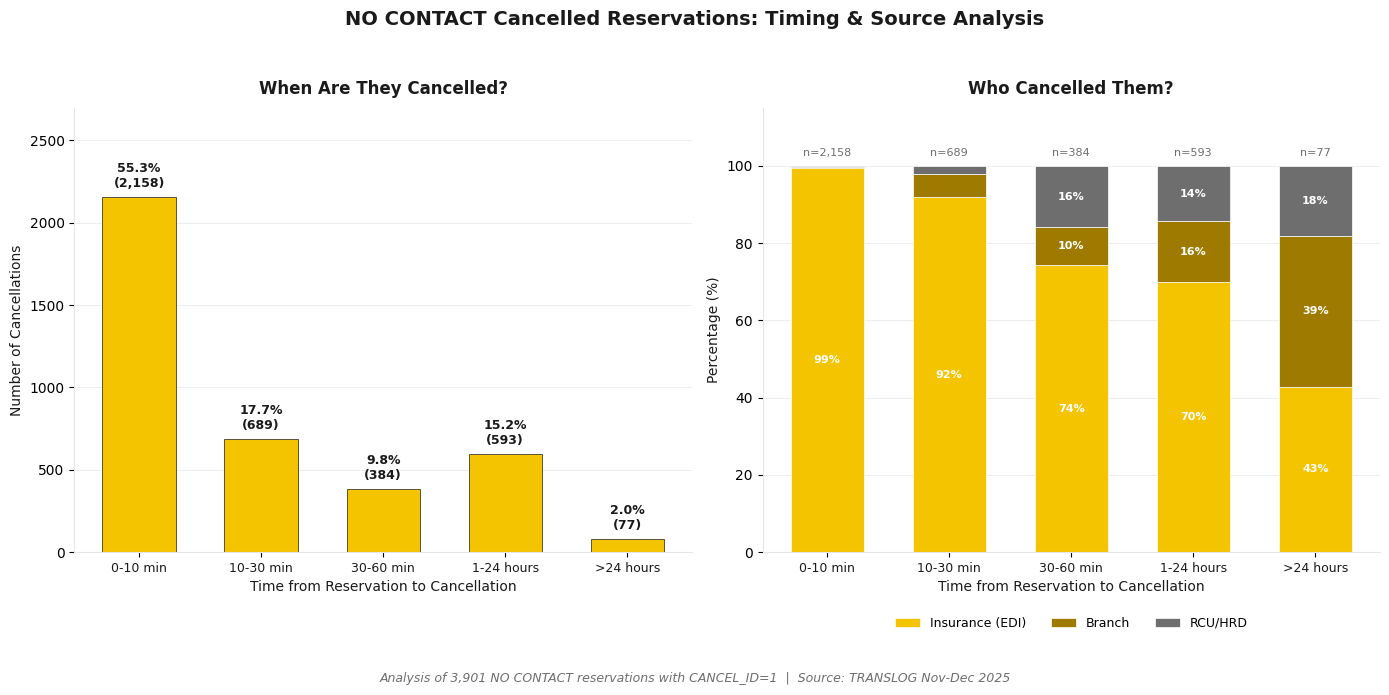


Chart saved to ../no_contact_cancellation_analysis.png


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white')

# ============ LEFT CHART: When Are They Cancelled? ============
ax1.set_facecolor('white')
x_pos = np.arange(len(bucket_order))
bars = ax1.bar(x_pos, counts, width=0.6, color=HERTZ_YELLOW, edgecolor=CHARCOAL, linewidth=0.5)

for i, (bar, pct, count) in enumerate(zip(bars, percentages, counts)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.02, 
             f'{pct:.1f}%\n({count:,})', ha='center', va='bottom', 
             fontsize=9, color=CHARCOAL, fontweight='bold')

# Calculate 30-min percentage for summary
pct_30min = percentages[0] + percentages[1]

ax1.set_xticks(x_pos)
ax1.set_xticklabels(bucket_order, fontsize=9, color=CHARCOAL)
ax1.set_xlabel('Time from Reservation to Cancellation', fontsize=10, color=CHARCOAL)
ax1.set_ylabel('Number of Cancellations', fontsize=10, color=CHARCOAL)
ax1.set_title('When Are They Cancelled?', fontsize=12, fontweight='bold', color=CHARCOAL, pad=10)
ax1.set_ylim(0, max(counts) * 1.25)
ax1.yaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax1.set_axisbelow(True)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color(LIGHT_GRAY)
ax1.spines['bottom'].set_color(LIGHT_GRAY)

# ============ RIGHT CHART: Who Cancelled Them? ============
ax2.set_facecolor('white')
categories = ['Insurance (EDI)', 'Branch', 'RCU/HRD']
bottom = np.zeros(len(bucket_order))

for cat in categories:
    values = [who_cancelled_pct.loc[tb, cat] if tb in who_cancelled_pct.index and cat in who_cancelled_pct.columns else 0 
              for tb in bucket_order]
    ax2.bar(x_pos, values, width=0.6, bottom=bottom, 
            color=colors[cat], edgecolor='white', linewidth=0.5, label=cat)
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val >= 8:
            ax2.text(x_pos[i], bot + val/2, f'{val:.0f}%', 
                     ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, values)]

for i, count in enumerate(counts):
    ax2.text(x_pos[i], 102, f'n={count:,}', ha='center', va='bottom', fontsize=8, color=DARK_GRAY)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(bucket_order, fontsize=9, color=CHARCOAL)
ax2.set_xlabel('Time from Reservation to Cancellation', fontsize=10, color=CHARCOAL)
ax2.set_ylabel('Percentage (%)', fontsize=10, color=CHARCOAL)
ax2.set_title('Who Cancelled Them?', fontsize=12, fontweight='bold', color=CHARCOAL, pad=10)
ax2.set_ylim(0, 115)
ax2.yaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax2.set_axisbelow(True)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color(LIGHT_GRAY)
ax2.spines['bottom'].set_color(LIGHT_GRAY)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=9)

# Main title and footer
fig.suptitle('NO CONTACT Cancelled Reservations: Timing & Source Analysis', 
             fontsize=14, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.5, 0.02, f'Analysis of {total_cancels:,} NO CONTACT reservations with CANCEL_ID=1  |  Source: TRANSLOG Nov-Dec 2025',
         ha='center', fontsize=9, color=DARK_GRAY, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('../no_contact_cancellation_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nChart saved to ../no_contact_cancellation_analysis.png')

## 6.5 CDP Breakdown: Cancellation vs Population Proportion

Are certain CDPs over-represented in NO CONTACT cancellations relative to their share of the overall lead population?

In [13]:
# Get CDP column name (handle newline prefix from Excel)
cdp_col = [c for c in conv.columns if 'CDP NAME' in c][0]
print(f'CDP column: {cdp_col!r}')

# Population proportion: all leads
pop_cdp = conv.groupby(cdp_col).size().reset_index(name='pop_count')
pop_cdp['pop_pct'] = pop_cdp['pop_count'] / pop_cdp['pop_count'].sum() * 100

# NO CONTACT cancelled reservations by CDP
no_contact_cancel_cdp = no_contact_cancel.groupby(cdp_col).size().reset_index(name='cancel_count')
no_contact_cancel_cdp['cancel_pct'] = no_contact_cancel_cdp['cancel_count'] / no_contact_cancel_cdp['cancel_count'].sum() * 100

# Merge
cdp_comparison = pop_cdp.merge(no_contact_cancel_cdp, on=cdp_col, how='outer').fillna(0)
cdp_comparison['diff_pct'] = cdp_comparison['cancel_pct'] - cdp_comparison['pop_pct']
cdp_comparison = cdp_comparison.sort_values('pop_count', ascending=False)

print(f"\nTotal CDPs: {len(cdp_comparison)}")
print(f"CDPs with cancellations: {(cdp_comparison['cancel_count'] > 0).sum()}")
print(f"\nTop 15 CDPs by volume:")
cdp_comparison.head(15)[[cdp_col, 'pop_count', 'pop_pct', 'cancel_count', 'cancel_pct', 'diff_pct']].round(1)

CDP column: '\nCDP NAME'

Total CDPs: 644
CDPs with cancellations: 269

Top 15 CDPs by volume:


,\nCDP NAME,pop_count,pop_pct,cancel_count,cancel_pct,diff_pct
592,STATE FARM-DULUTH HIRS,19419,28.4,2017.0,46.4,18.0
598,STATE FARM-TEMPE HIRS,16271,23.8,802.0,18.5,-5.3
116,COMMERCE INS-WEBSTER HIRS,3030,4.4,101.0,2.3,-2.1
591,STATE FARM-DALLAS HIRS,2503,3.7,117.0,2.7,-1.0
604,TESLA INSURANCE CLAIMS,1931,2.8,58.0,1.3,-1.5
587,STATE FARM-BLOOMINGTON HIRS,1631,2.4,92.0,2.1,-0.3
120,COOPERATORS (CGIC) HIRS,1279,1.9,29.0,0.7,-1.2
136,ELEPHANT INS-GLEN ALLEN HIRS,637,0.9,16.0,0.4,-0.6
191,FIRST ACCEPT-NASHVLL HIRS,550,0.8,25.0,0.6,-0.2
127,CSAA OKLAHOMA CITY,505,0.7,18.0,0.4,-0.3


In [14]:
# Breakdown by time bucket: which CDPs are cancelling in each window?
# Merge CDP info into cancel_with_time
cancel_with_time_cdp = cancel_with_time.merge(
    no_contact_cancel[['\nCONFIRM_NUM', cdp_col]].drop_duplicates(),
    left_on='res_id',
    right_on=no_contact_cancel['\nCONFIRM_NUM'].astype(str).str.strip().values,
    how='left'
)

# CDP counts by time bucket
cdp_by_bucket = cancel_with_time_cdp.groupby(['time_bucket', cdp_col]).size().unstack(fill_value=0)
cdp_by_bucket = cdp_by_bucket.reindex(bucket_order)

# Get top 10 CDPs by total cancellation volume
top_cdps = cdp_by_bucket.sum().nlargest(10).index.tolist()
print(f"Top 10 CDPs by cancellation volume:")
for i, cdp in enumerate(top_cdps, 1):
    total = cdp_by_bucket[cdp].sum()
    print(f"  {i}. {cdp}: {total:,} cancellations")

Top 10 CDPs by cancellation volume:
  1. STATE FARM-DULUTH HIRS: 1,803 cancellations
  2. STATE FARM-TEMPE HIRS: 701 cancellations
  3. STATE FARM-DALLAS HIRS: 112 cancellations
  4. COMMERCE INS-WEBSTER HIRS: 101 cancellations
  5. STATE FARM-BLOOMINGTON HIRS: 79 cancellations
  6. TESLA INSURANCE CLAIMS: 58 cancellations
  7. PLYMOUTH ROCK ASSURANCE: 48 cancellations
  8. COOPERATORS (CGIC) HIRS: 30 cancellations
  9. AMERICAN AUTO SHIELD LLC: 29 cancellations
  10. MAPFRE INS GROUP WEBSTER: 29 cancellations


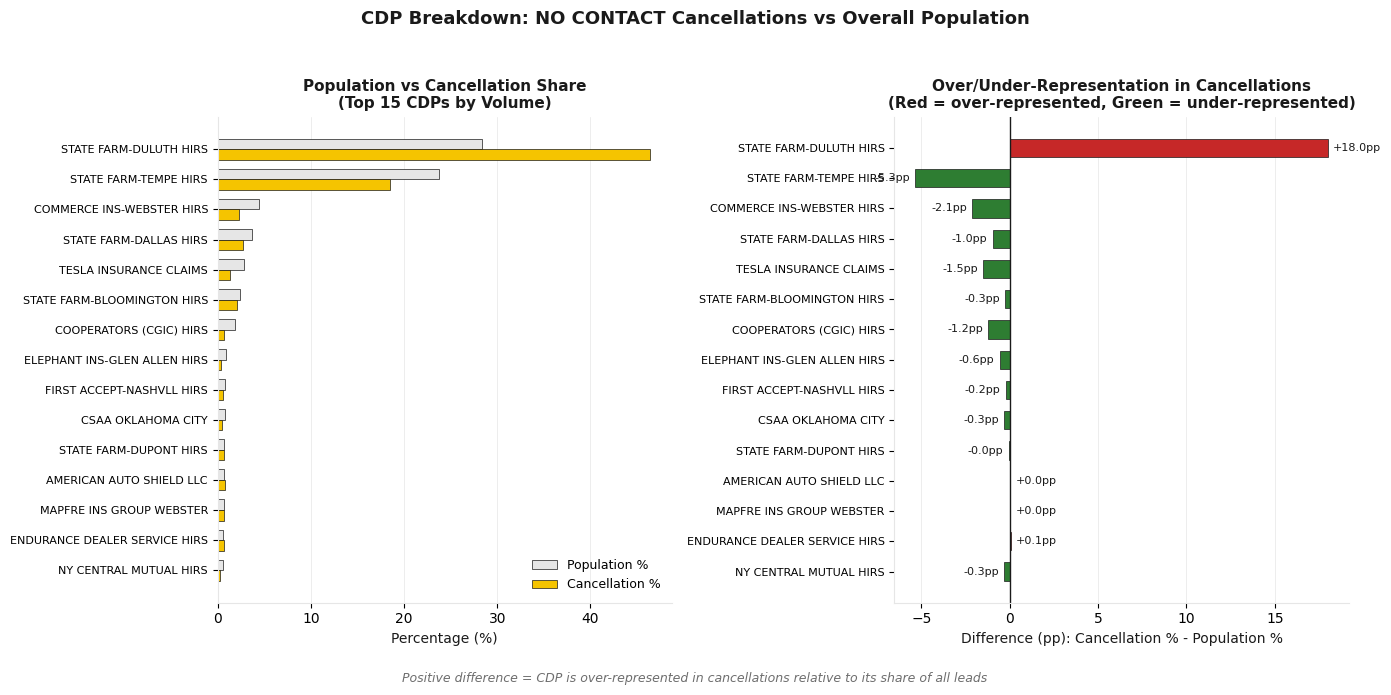

In [15]:
# Create visualization: CDP Population vs Cancellation Proportion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white')

# Filter to top 15 CDPs by population for readability
top15_cdps = cdp_comparison.head(15).copy()

# LEFT CHART: Side-by-side bar comparison
ax1.set_facecolor('white')
y_pos = np.arange(len(top15_cdps))
bar_height = 0.35

bars1 = ax1.barh(y_pos - bar_height/2, top15_cdps['pop_pct'], bar_height, 
                  label='Population %', color=LIGHT_GRAY, edgecolor=CHARCOAL, linewidth=0.5)
bars2 = ax1.barh(y_pos + bar_height/2, top15_cdps['cancel_pct'], bar_height,
                  label='Cancellation %', color=HERTZ_YELLOW, edgecolor=CHARCOAL, linewidth=0.5)

ax1.set_yticks(y_pos)
ax1.set_yticklabels([name[:35] if len(name) <= 35 else name[:32] + '...' for name in top15_cdps[cdp_col]], fontsize=8)
ax1.set_xlabel('Percentage (%)', fontsize=10, color=CHARCOAL)
ax1.set_title('Population vs Cancellation Share\n(Top 15 CDPs by Volume)', fontsize=11, fontweight='bold', color=CHARCOAL)
ax1.legend(loc='lower right', fontsize=9, frameon=False)
ax1.xaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax1.set_axisbelow(True)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color(LIGHT_GRAY)
ax1.spines['bottom'].set_color(LIGHT_GRAY)
ax1.invert_yaxis()

# RIGHT CHART: Difference (over/under-representation)
ax2.set_facecolor('white')
colors_diff = [RED if x > 0 else '#2E7D32' for x in top15_cdps['diff_pct']]
bars3 = ax2.barh(y_pos, top15_cdps['diff_pct'], 0.6, color=colors_diff, edgecolor=CHARCOAL, linewidth=0.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars3, top15_cdps['diff_pct'])):
    x_pos = val + 0.3 if val >= 0 else val - 0.3
    ha = 'left' if val >= 0 else 'right'
    ax2.text(x_pos, i, f'{val:+.1f}pp', va='center', ha=ha, fontsize=8, color=CHARCOAL)

ax2.axvline(x=0, color=CHARCOAL, linewidth=1)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([name[:35] if len(name) <= 35 else name[:32] + '...' for name in top15_cdps[cdp_col]], fontsize=8)
ax2.set_xlabel('Difference (pp): Cancellation % - Population %', fontsize=10, color=CHARCOAL)
ax2.set_title('Over/Under-Representation in Cancellations\n(Red = over-represented, Green = under-represented)', fontsize=11, fontweight='bold', color=CHARCOAL)
ax2.xaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax2.set_axisbelow(True)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color(LIGHT_GRAY)
ax2.spines['bottom'].set_color(LIGHT_GRAY)
ax2.invert_yaxis()

fig.suptitle('CDP Breakdown: NO CONTACT Cancellations vs Overall Population', 
             fontsize=13, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.5, 0.02, 'Positive difference = CDP is over-represented in cancellations relative to its share of all leads',
         ha='center', fontsize=9, color=DARK_GRAY, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [16]:
# CDP breakdown by time bucket (top 10 CDPs)
cdp_bucket_top10 = cdp_by_bucket[top_cdps].copy()
cdp_bucket_pct = cdp_bucket_top10.div(cdp_bucket_top10.sum(axis=1), axis=0) * 100

print("CDP Share of Cancellations by Time Bucket (Top 10 CDPs):")
print(cdp_bucket_pct.round(1))
print(f"\nNote: These top 10 CDPs account for {cdp_bucket_top10.sum().sum() / cancel_with_time_cdp.shape[0] * 100:.1f}% of all cancellations")

CDP Share of Cancellations by Time Bucket (Top 10 CDPs):

CDP NAME    STATE FARM-DULUTH HIRS  STATE FARM-TEMPE HIRS  \
time_bucket                                                  
0-10 min                       62.4                   26.4   
10-30 min                      66.7                   19.2   
30-60 min                      58.3                   20.1   
1-24 hours                     47.3                   20.8   
>24 hours                      28.6                    5.7   


CDP NAME    STATE FARM-DALLAS HIRS  COMMERCE INS-WEBSTER HIRS  \
time_bucket                                                      
0-10 min                        4.0                        1.0   
10-30 min                       2.9                        2.7   
30-60 min                       4.9                        6.6   
1-24 hours                      2.9                       11.2   
>24 hours                       5.7                        8.6   


CDP NAME    STATE FARM-BLOOMINGTON HIRS  TES

In [17]:
# Summary table: CDPs with significant over/under-representation
print("="*70)
print("CDP REPRESENTATION ANALYSIS SUMMARY")
print("="*70)

# CDPs significantly over-represented (>2pp difference, min 50 cancellations)
over_rep = cdp_comparison[(cdp_comparison['diff_pct'] > 2) & (cdp_comparison['cancel_count'] >= 50)].sort_values('diff_pct', ascending=False)
print(f"\nCDPs OVER-REPRESENTED in cancellations (>2pp, n≥50):")
if len(over_rep) > 0:
    for _, row in over_rep.head(10).iterrows():
        print(f"  {row[cdp_col][:40]:<40} Pop: {row['pop_pct']:>5.1f}%  Cancel: {row['cancel_pct']:>5.1f}%  Diff: {row['diff_pct']:>+5.1f}pp")
else:
    print("  None")

# CDPs significantly under-represented (<-2pp difference, min 100 population)
under_rep = cdp_comparison[(cdp_comparison['diff_pct'] < -2) & (cdp_comparison['pop_count'] >= 100)].sort_values('diff_pct')
print(f"\nCDPs UNDER-REPRESENTED in cancellations (<-2pp, n≥100):")
if len(under_rep) > 0:
    for _, row in under_rep.head(10).iterrows():
        print(f"  {row[cdp_col][:40]:<40} Pop: {row['pop_pct']:>5.1f}%  Cancel: {row['cancel_pct']:>5.1f}%  Diff: {row['diff_pct']:>+5.1f}pp")
else:
    print("  None")

print(f"\n--- Key Insight ---")
print("CDPs over-represented in cancellations may indicate:")
print("  - Insurance partners with higher churn/shopping behavior")
print("  - Partners where customers are more likely to find alternatives")
print("CDPs under-represented may indicate:")
print("  - More committed/captive customer base")
print("  - Better alignment between Hertz and partner expectations")

CDP REPRESENTATION ANALYSIS SUMMARY

CDPs OVER-REPRESENTED in cancellations (>2pp, n≥50):
  STATE FARM-DULUTH HIRS                   Pop:  28.4%  Cancel:  46.4%  Diff: +18.0pp

CDPs UNDER-REPRESENTED in cancellations (<-2pp, n≥100):
  STATE FARM-TEMPE HIRS                    Pop:  23.8%  Cancel:  18.5%  Diff:  -5.3pp
  COMMERCE INS-WEBSTER HIRS                Pop:   4.4%  Cancel:   2.3%  Diff:  -2.1pp

--- Key Insight ---
CDPs over-represented in cancellations may indicate:
  - Insurance partners with higher churn/shopping behavior
  - Partners where customers are more likely to find alternatives
CDPs under-represented may indicate:
  - More committed/captive customer base
  - Better alignment between Hertz and partner expectations


In [18]:
# Focus on early cancellations (within 30 minutes)
early_cancels = cancel_with_time_cdp[cancel_with_time_cdp['time_bucket'].isin(['0-10 min', '10-30 min'])]
print(f"Cancellations within 30 minutes: {len(early_cancels):,}")

# CDP breakdown for early cancellations
early_cdp = early_cancels.groupby(cdp_col).size().reset_index(name='early_cancel_count')
early_cdp['early_cancel_pct'] = early_cdp['early_cancel_count'] / early_cdp['early_cancel_count'].sum() * 100

# Merge with population data
early_comparison = pop_cdp.merge(early_cdp, on=cdp_col, how='outer').fillna(0)
early_comparison['early_diff_pct'] = early_comparison['early_cancel_pct'] - early_comparison['pop_pct']
early_comparison = early_comparison.sort_values('pop_count', ascending=False)

print(f"\nTop 15 CDPs - Early Cancellation (<30 min) vs Population:")
early_comparison.head(15)[[cdp_col, 'pop_count', 'pop_pct', 'early_cancel_count', 'early_cancel_pct', 'early_diff_pct']].round(1)

Cancellations within 30 minutes: 2,847

Top 15 CDPs - Early Cancellation (<30 min) vs Population:


,\nCDP NAME,pop_count,pop_pct,early_cancel_count,early_cancel_pct,early_diff_pct
592,STATE FARM-DULUTH HIRS,19419,28.4,1427.0,50.1,21.7
598,STATE FARM-TEMPE HIRS,16271,23.8,554.0,19.5,-4.3
116,COMMERCE INS-WEBSTER HIRS,3030,4.4,32.0,1.1,-3.3
591,STATE FARM-DALLAS HIRS,2503,3.7,84.0,3.0,-0.7
604,TESLA INSURANCE CLAIMS,1931,2.8,32.0,1.1,-1.7
587,STATE FARM-BLOOMINGTON HIRS,1631,2.4,63.0,2.2,-0.2
120,COOPERATORS (CGIC) HIRS,1279,1.9,10.0,0.4,-1.5
136,ELEPHANT INS-GLEN ALLEN HIRS,637,0.9,12.0,0.4,-0.5
191,FIRST ACCEPT-NASHVLL HIRS,550,0.8,18.0,0.6,-0.2
127,CSAA OKLAHOMA CITY,505,0.7,10.0,0.4,-0.4


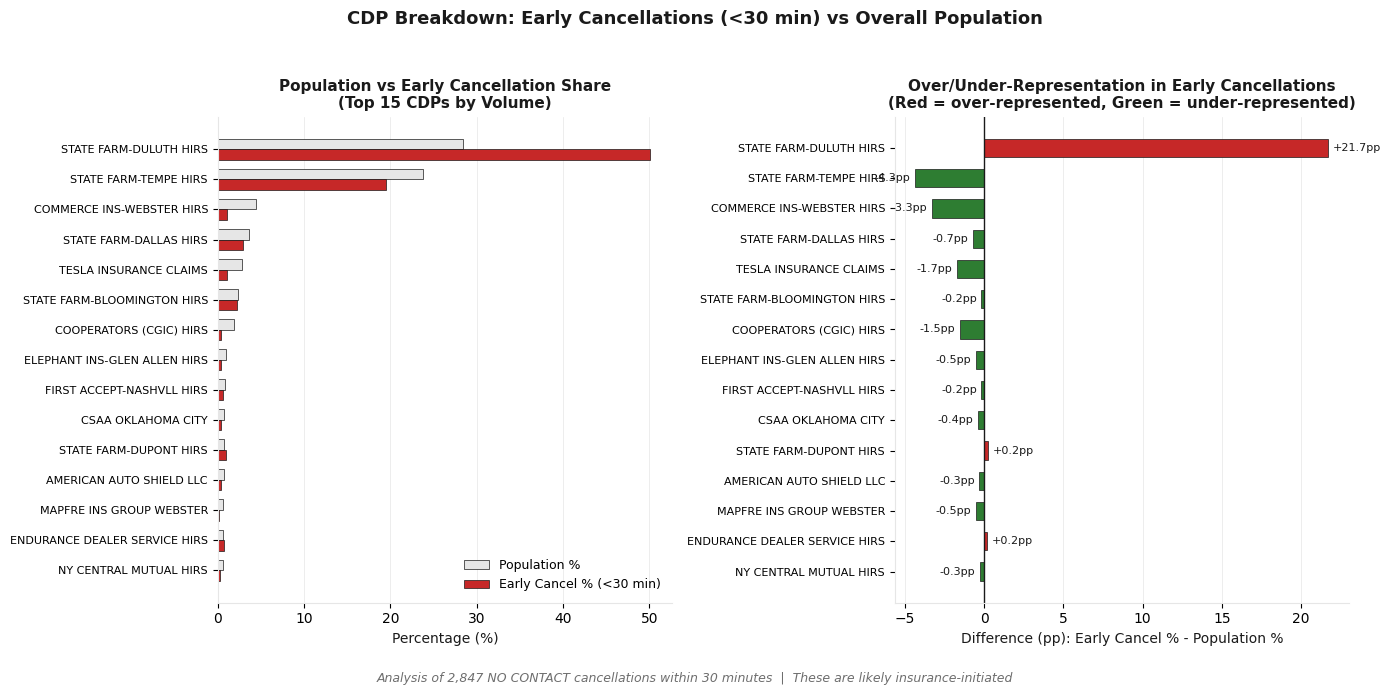

In [19]:
# Visualization: Early Cancellations (<30 min) by CDP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white')

# Filter to top 15 CDPs by population
top15_early = early_comparison.head(15).copy()

# LEFT CHART: Side-by-side comparison
ax1.set_facecolor('white')
y_pos = np.arange(len(top15_early))
bar_height = 0.35

bars1 = ax1.barh(y_pos - bar_height/2, top15_early['pop_pct'], bar_height, 
                  label='Population %', color=LIGHT_GRAY, edgecolor=CHARCOAL, linewidth=0.5)
bars2 = ax1.barh(y_pos + bar_height/2, top15_early['early_cancel_pct'], bar_height,
                  label='Early Cancel % (<30 min)', color=RED, edgecolor=CHARCOAL, linewidth=0.5)

ax1.set_yticks(y_pos)
ax1.set_yticklabels([name[:35] if len(name) <= 35 else name[:32] + '...' for name in top15_early[cdp_col]], fontsize=8)
ax1.set_xlabel('Percentage (%)', fontsize=10, color=CHARCOAL)
ax1.set_title('Population vs Early Cancellation Share\n(Top 15 CDPs by Volume)', fontsize=11, fontweight='bold', color=CHARCOAL)
ax1.legend(loc='lower right', fontsize=9, frameon=False)
ax1.xaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax1.set_axisbelow(True)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color(LIGHT_GRAY)
ax1.spines['bottom'].set_color(LIGHT_GRAY)
ax1.invert_yaxis()

# RIGHT CHART: Difference
ax2.set_facecolor('white')
colors_diff = [RED if x > 0 else '#2E7D32' for x in top15_early['early_diff_pct']]
bars3 = ax2.barh(y_pos, top15_early['early_diff_pct'], 0.6, color=colors_diff, edgecolor=CHARCOAL, linewidth=0.5)

for i, (bar, val) in enumerate(zip(bars3, top15_early['early_diff_pct'])):
    x_pos = val + 0.3 if val >= 0 else val - 0.3
    ha = 'left' if val >= 0 else 'right'
    ax2.text(x_pos, i, f'{val:+.1f}pp', va='center', ha=ha, fontsize=8, color=CHARCOAL)

ax2.axvline(x=0, color=CHARCOAL, linewidth=1)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([name[:35] if len(name) <= 35 else name[:32] + '...' for name in top15_early[cdp_col]], fontsize=8)
ax2.set_xlabel('Difference (pp): Early Cancel % - Population %', fontsize=10, color=CHARCOAL)
ax2.set_title('Over/Under-Representation in Early Cancellations\n(Red = over-represented, Green = under-represented)', fontsize=11, fontweight='bold', color=CHARCOAL)
ax2.xaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax2.set_axisbelow(True)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color(LIGHT_GRAY)
ax2.spines['bottom'].set_color(LIGHT_GRAY)
ax2.invert_yaxis()

fig.suptitle('CDP Breakdown: Early Cancellations (<30 min) vs Overall Population', 
             fontsize=13, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.5, 0.02, f'Analysis of {len(early_cancels):,} NO CONTACT cancellations within 30 minutes  |  These are likely insurance-initiated',
         ha='center', fontsize=9, color=DARK_GRAY, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [20]:
# Summary: CDPs over/under-represented in EARLY cancellations (<30 min)
print("="*70)
print("EARLY CANCELLATION (<30 MIN) CDP ANALYSIS")
print("="*70)

# CDPs over-represented in early cancellations
early_over = early_comparison[(early_comparison['early_diff_pct'] > 2) & (early_comparison['early_cancel_count'] >= 30)].sort_values('early_diff_pct', ascending=False)
print(f"\nCDPs OVER-REPRESENTED in early cancellations (>2pp, n≥30):")
if len(early_over) > 0:
    for _, row in early_over.head(10).iterrows():
        print(f"  {row[cdp_col][:40]:<40} Pop: {row['pop_pct']:>5.1f}%  Early: {row['early_cancel_pct']:>5.1f}%  Diff: {row['early_diff_pct']:>+5.1f}pp")
else:
    print("  None")

# CDPs under-represented in early cancellations
early_under = early_comparison[(early_comparison['early_diff_pct'] < -2) & (early_comparison['pop_count'] >= 100)].sort_values('early_diff_pct')
print(f"\nCDPs UNDER-REPRESENTED in early cancellations (<-2pp, n≥100):")
if len(early_under) > 0:
    for _, row in early_under.head(10).iterrows():
        print(f"  {row[cdp_col][:40]:<40} Pop: {row['pop_pct']:>5.1f}%  Early: {row['early_cancel_pct']:>5.1f}%  Diff: {row['early_diff_pct']:>+5.1f}pp")
else:
    print("  None")

print(f"\n--- Key Insight ---")
print("CDPs over-represented in early (<30 min) cancellations likely have:")
print("  - Insurance adjusters who quickly shop/cancel across multiple providers")
print("  - Automated systems that cancel rapidly when alternatives are found")
print("These represent the highest-risk leads where speed-to-contact is critical.")

EARLY CANCELLATION (<30 MIN) CDP ANALYSIS

CDPs OVER-REPRESENTED in early cancellations (>2pp, n≥30):
  STATE FARM-DULUTH HIRS                   Pop:  28.4%  Early:  50.1%  Diff: +21.7pp

CDPs UNDER-REPRESENTED in early cancellations (<-2pp, n≥100):
  STATE FARM-TEMPE HIRS                    Pop:  23.8%  Early:  19.5%  Diff:  -4.3pp
  COMMERCE INS-WEBSTER HIRS                Pop:   4.4%  Early:   1.1%  Diff:  -3.3pp

--- Key Insight ---
CDPs over-represented in early (<30 min) cancellations likely have:
  - Insurance adjusters who quickly shop/cancel across multiple providers
  - Automated systems that cancel rapidly when alternatives are found
These represent the highest-risk leads where speed-to-contact is critical.


## 7. Summary

In [21]:
print('='*60)
print('SUMMARY')
print('='*60)
print(f'\nTotal NO CONTACT cancelled reservations: {len(no_contact_confirms):,}')
print(f'Cancellation events found in Translog: {len(cancel_with_time):,}')
print(f'Coverage: {len(cancel_with_time)/len(no_contact_confirms)*100:.1f}%')

print(f'\nCancellation Source Breakdown:')
source_totals = cancel_with_time['cancel_source'].value_counts()
for source in ['Insurance (EDI)', 'Branch', 'RCU/HRD']:
    if source in source_totals:
        count = source_totals[source]
        pct = count / len(cancel_with_time) * 100
        print(f'  {source}: {count:,} ({pct:.1f}%)')

print(f'\nKey Insight:')
print(f'  {pct_30min:.0f}% of NO CONTACT cancellations happen within 30 minutes')
early_edi_pct = who_cancelled_pct.loc['0-10 min', 'Insurance (EDI)']
print(f'  {early_edi_pct:.0f}% of 0-10 min cancellations are by Insurance (EDI)')

SUMMARY

Total NO CONTACT cancelled reservations: 4,346
Cancellation events found in Translog: 3,901
Coverage: 89.8%

Cancellation Source Breakdown:
  Insurance (EDI): 3,509 (90.0%)
  Branch: 214 (5.5%)
  RCU/HRD: 178 (4.6%)

Key Insight:
  73% of NO CONTACT cancellations happen within 30 minutes
  99% of 0-10 min cancellations are by Insurance (EDI)


## Part 2: HRD & COUNTER Contacted Cancelled Reservations

This section analyzes cancellations for reservations where Hertz **did** make contact (HRD or Counter), to compare with NO CONTACT cancellations.

In [22]:
# Filter to HRD and COUNTER contacted + CANCEL_ID = 1 (exclude NO CONTACT)
contacted_cancel = conv[
    (conv['\nCONTACT_GROUP'].isin(['HRD - OKC', 'COUNTER'])) & 
    (conv['\nCANCEL_ID'] == 1)
].copy()
contacted_confirms = set(contacted_cancel['\nCONFIRM_NUM'].astype(str).str.strip())
print(f'HRD/Counter contacted cancelled reservations: {len(contacted_confirms):,}')
print(contacted_cancel['\nCONTACT_GROUP'].value_counts())

HRD/Counter contacted cancelled reservations: 9,356
\nCONTACT_GROUP
COUNTER      4785
HRD - OKC    4571
Name: count, dtype: int64


In [23]:
# Get EDI cancellations for contacted reservations
edi_cancels_c = translog[(translog['MSG1'] == 'Edi-Cancel') & (translog['EMP_LNAME'] == 'EDI')].copy()
edi_cancels_c['res_id'] = edi_cancels_c['Knum'].astype(str).str.strip()
edi_cancels_c = edi_cancels_c[edi_cancels_c['res_id'].isin(contacted_confirms)]
edi_cancels_c['cancel_source'] = 'Insurance (EDI)'
print(f'EDI cancellations: {len(edi_cancels_c):,}')

# Get Rez-Cancelled for contacted reservations
rez_cancels_c = translog[translog['MSG1'] == 'Rez-Cancelled'].copy()
rez_cancels_c['res_id'] = rez_cancels_c['REZ_NUM'].astype(str).str.strip()
rez_cancels_c = rez_cancels_c[rez_cancels_c['res_id'].isin(contacted_confirms)]
rez_cancels_c['cancel_source'] = rez_cancels_c['LocCode'].apply(lambda x: 'RCU/HRD' if str(x) == '12' else 'Branch')
print(f'Rez-Cancelled: {len(rez_cancels_c):,}')
print(rez_cancels_c['cancel_source'].value_counts())

# Combine
all_cancels_c = pd.concat([edi_cancels_c, rez_cancels_c], ignore_index=True)
print(f'Total cancellation events: {len(all_cancels_c):,}')

EDI cancellations: 6,353
Rez-Cancelled: 2,649
cancel_source
Branch     2387
RCU/HRD     262
Name: count, dtype: int64
Total cancellation events: 9,002


In [24]:
# Parse timestamps and calculate time to cancellation
all_cancels_c['cancel_datetime'] = pd.to_datetime(all_cancels_c['SystemDate'].astype(str), format='%Y%m%d%H%M%S', errors='coerce')

# Get first events for contacted reservations
first_events_c = translog[translog['res_id'].isin(contacted_confirms)].groupby('res_id')['event_datetime'].min().reset_index()
first_events_c.columns = ['res_id', 'creation_datetime']

cancel_with_time_c = all_cancels_c.merge(first_events_c, on='res_id', how='left')
cancel_with_time_c['time_to_cancel_mins'] = (cancel_with_time_c['cancel_datetime'] - cancel_with_time_c['creation_datetime']).dt.total_seconds() / 60
cancel_with_time_c = cancel_with_time_c[(cancel_with_time_c['time_to_cancel_mins'] > 0) & (cancel_with_time_c['time_to_cancel_mins'].notna())]

cancel_with_time_c['time_bucket'] = cancel_with_time_c['time_to_cancel_mins'].apply(time_bucket)
print(f'Records with valid time: {len(cancel_with_time_c):,}')

Records with valid time: 9,002


In [25]:
# Aggregate data for contacted cancellations
when_cancelled_c = cancel_with_time_c.groupby('time_bucket').size().reindex(bucket_order).fillna(0).astype(int)
total_cancels_c = when_cancelled_c.sum()
when_pct_c = (when_cancelled_c / total_cancels_c * 100).round(1)

who_cancelled_c = cancel_with_time_c.groupby(['time_bucket', 'cancel_source']).size().unstack(fill_value=0)
who_cancelled_c = who_cancelled_c.reindex(bucket_order)
who_cancelled_pct_c = who_cancelled_c.div(who_cancelled_c.sum(axis=1), axis=0) * 100

print('When Are They Cancelled?')
for bucket in bucket_order:
    print(f'  {bucket}: {when_cancelled_c[bucket]:,} ({when_pct_c[bucket]:.1f}%)')

print('\nWho Cancelled Them? (percentages)')
print(who_cancelled_pct_c.round(1))

When Are They Cancelled?
  0-10 min: 48 (0.5%)
  10-30 min: 260 (2.9%)
  30-60 min: 463 (5.1%)
  1-24 hours: 2,951 (32.8%)
  >24 hours: 5,280 (58.7%)

Who Cancelled Them? (percentages)
cancel_source  Branch  Insurance (EDI)  RCU/HRD
time_bucket                                    
0-10 min         37.5             58.3      4.2
10-30 min        16.9             78.5      4.6
30-60 min        11.0             79.5      9.5
1-24 hours       15.0             81.0      4.0
>24 hours        34.7             63.7      1.6


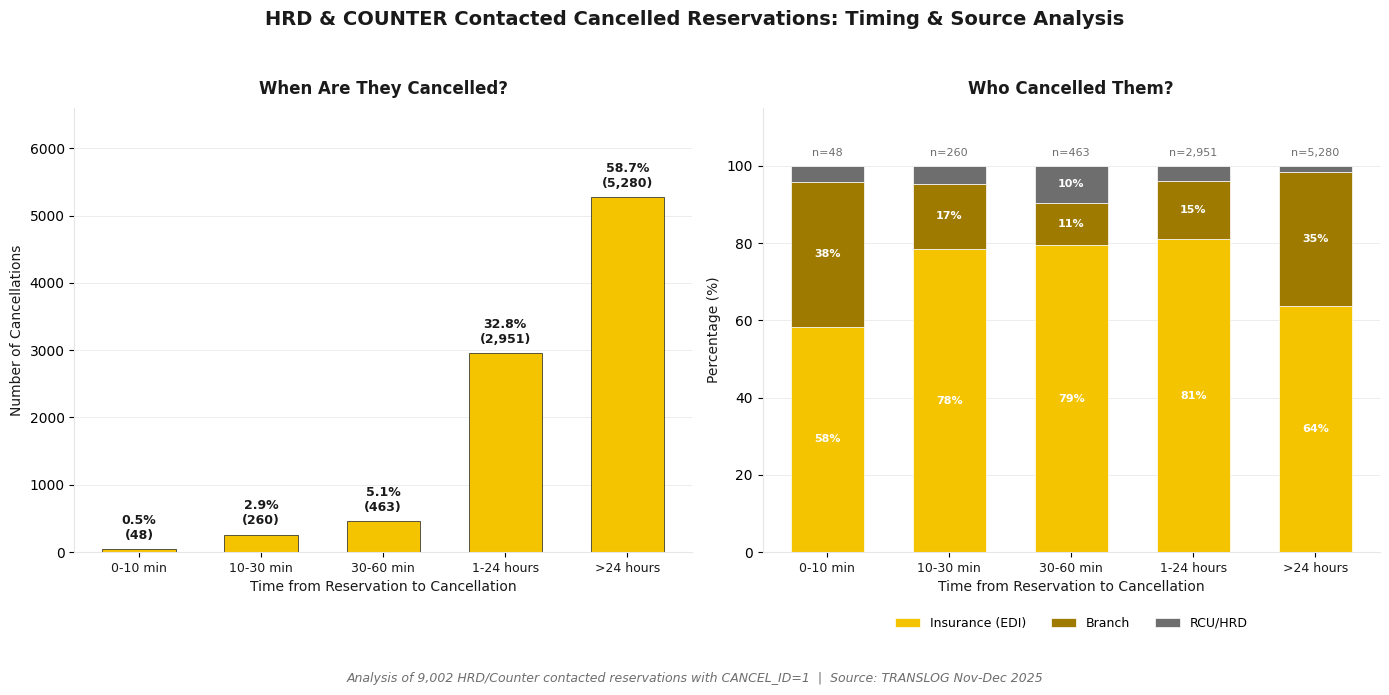


Chart saved to ../contacted_cancellation_analysis.png


In [26]:
# Create chart for contacted cancellations
counts_c = [when_cancelled_c[b] for b in bucket_order]
percentages_c = [when_pct_c[b] for b in bucket_order]

for col in colors.keys():
    if col not in who_cancelled_pct_c.columns:
        who_cancelled_pct_c[col] = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('white')

# LEFT CHART
ax1.set_facecolor('white')
x_pos = np.arange(len(bucket_order))
bars = ax1.bar(x_pos, counts_c, width=0.6, color=HERTZ_YELLOW, edgecolor=CHARCOAL, linewidth=0.5)

for i, (bar, pct, count) in enumerate(zip(bars, percentages_c, counts_c)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_c)*0.02, 
             f'{pct:.1f}%\n({count:,})', ha='center', va='bottom', fontsize=9, color=CHARCOAL, fontweight='bold')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(bucket_order, fontsize=9, color=CHARCOAL)
ax1.set_xlabel('Time from Reservation to Cancellation', fontsize=10, color=CHARCOAL)
ax1.set_ylabel('Number of Cancellations', fontsize=10, color=CHARCOAL)
ax1.set_title('When Are They Cancelled?', fontsize=12, fontweight='bold', color=CHARCOAL, pad=10)
ax1.set_ylim(0, max(counts_c) * 1.25)
ax1.yaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax1.set_axisbelow(True)
for spine in ['top', 'right']: ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color(LIGHT_GRAY)
ax1.spines['bottom'].set_color(LIGHT_GRAY)

# RIGHT CHART
ax2.set_facecolor('white')
categories = ['Insurance (EDI)', 'Branch', 'RCU/HRD']
bottom = np.zeros(len(bucket_order))
for cat in categories:
    values = [who_cancelled_pct_c.loc[tb, cat] if tb in who_cancelled_pct_c.index and cat in who_cancelled_pct_c.columns else 0 for tb in bucket_order]
    ax2.bar(x_pos, values, width=0.6, bottom=bottom, color=colors[cat], edgecolor='white', linewidth=0.5, label=cat)
    for i, (val, bot) in enumerate(zip(values, bottom)):
        if val >= 8:
            ax2.text(x_pos[i], bot + val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom = [b + v for b, v in zip(bottom, values)]

for i, count in enumerate(counts_c):
    ax2.text(x_pos[i], 102, f'n={count:,}', ha='center', va='bottom', fontsize=8, color=DARK_GRAY)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(bucket_order, fontsize=9, color=CHARCOAL)
ax2.set_xlabel('Time from Reservation to Cancellation', fontsize=10, color=CHARCOAL)
ax2.set_ylabel('Percentage (%)', fontsize=10, color=CHARCOAL)
ax2.set_title('Who Cancelled Them?', fontsize=12, fontweight='bold', color=CHARCOAL, pad=10)
ax2.set_ylim(0, 115)
ax2.yaxis.grid(True, color=LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=0)
ax2.set_axisbelow(True)
for spine in ['top', 'right']: ax2.spines[spine].set_visible(False)
ax2.spines['left'].set_color(LIGHT_GRAY)
ax2.spines['bottom'].set_color(LIGHT_GRAY)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=9)

fig.suptitle('HRD & COUNTER Contacted Cancelled Reservations: Timing & Source Analysis', fontsize=14, fontweight='bold', color=CHARCOAL, y=0.98)
fig.text(0.5, 0.02, f'Analysis of {total_cancels_c:,} HRD/Counter contacted reservations with CANCEL_ID=1  |  Source: TRANSLOG Nov-Dec 2025',
         ha='center', fontsize=9, color=DARK_GRAY, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('../contacted_cancellation_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nChart saved to ../contacted_cancellation_analysis.png')

## Comparison: NO CONTACT vs HRD/Counter Contacted

In [27]:
print('='*70)
print('COMPARISON: NO CONTACT vs HRD/COUNTER CONTACTED')
print('='*70)

print('\n--- When Are They Cancelled? ---')
print(f'{"Time Bucket":<15} {"NO CONTACT":>15} {"HRD/Counter":>15}')
print('-'*50)
for bucket in bucket_order:
    nc_pct = when_pct[bucket]
    c_pct = when_pct_c[bucket]
    print(f'{bucket:<15} {nc_pct:>14.1f}% {c_pct:>14.1f}%')

print('\n--- Key Insight ---')
print(f'NO CONTACT: {when_pct["0-10 min"] + when_pct["10-30 min"]:.0f}% cancel within 30 minutes')
print(f'HRD/Counter: {when_pct_c["0-10 min"] + when_pct_c["10-30 min"]:.0f}% cancel within 30 minutes')
print(f'\nNO CONTACT: {when_pct[">24 hours"]:.0f}% cancel after >24 hours')
print(f'HRD/Counter: {when_pct_c[">24 hours"]:.0f}% cancel after >24 hours')

print('\n--- Interpretation ---')
print('NO CONTACT reservations are cancelled quickly (73% within 30 min) by insurance EDI.')
print('HRD/Counter contacted reservations take much longer to cancel (59% after >24 hours).')
print('This suggests insurance adjusters cancel before Hertz can make contact.')

COMPARISON: NO CONTACT vs HRD/COUNTER CONTACTED

--- When Are They Cancelled? ---
Time Bucket          NO CONTACT     HRD/Counter
--------------------------------------------------
0-10 min                  55.3%            0.5%
10-30 min                 17.7%            2.9%
30-60 min                  9.8%            5.1%
1-24 hours                15.2%           32.8%
>24 hours                  2.0%           58.7%

--- Key Insight ---
NO CONTACT: 73% cancel within 30 minutes
HRD/Counter: 3% cancel within 30 minutes

NO CONTACT: 2% cancel after >24 hours
HRD/Counter: 59% cancel after >24 hours

--- Interpretation ---
NO CONTACT reservations are cancelled quickly (73% within 30 min) by insurance EDI.
HRD/Counter contacted reservations take much longer to cancel (59% after >24 hours).
This suggests insurance adjusters cancel before Hertz can make contact.
